In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from collections import Counter
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


##To Do
# Apply in depth text preprocessing before EDA
# Conduct in depth setence analysis
# Try multiple models
# Implement Hyperparameter tuning
# Implement Ensemble methods- like stacking or voting classifiers- using top 3 models
# Bonus you can try to reduce classes to Positive and Negative (to handle bias your models are creating)
```
# This is formatted as code
```



In [ ]:
df = pd.read_csv('/content/Amazon-Product-Reviews.csv')

In [ ]:
df

,Review,Sentiment
0,Fast shipping but this product is very cheaply...,1
1,This case takes so long to ship and it's not e...,1
2,Good for not droids. Not good for iPhones. You...,1
3,The cable was not compatible between my macboo...,1
4,The case is nice but did not have a glow light...,1
...,...,...
24995,These cables (lightning) are far superior to m...,5
24996,This unit performs exactly as advertised. I u...,5
24997,I had the key cut at a local hardware store cu...,5
24998,I love my case I ordered from amazon. It wasn'...,5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Review     24999 non-null  object
 1   Sentiment  25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB


In [ ]:
df = df.dropna()
df['Review'] = df['Review'].astype(str)

/tmp/ipykernel_110202/1203332215.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Review'] = df['Review'].astype(str)


In [ ]:
df

,Review,Sentiment
0,Fast shipping but this product is very cheaply...,1
1,This case takes so long to ship and it's not e...,1
2,Good for not droids. Not good for iPhones. You...,1
3,The cable was not compatible between my macboo...,1
4,The case is nice but did not have a glow light...,1
...,...,...
24995,These cables (lightning) are far superior to m...,5
24996,This unit performs exactly as advertised. I u...,5
24997,I had the key cut at a local hardware store cu...,5
24998,I love my case I ordered from amazon. It wasn'...,5


In [ ]:
def categorize_rating(x):
    if x == 1:
        return "Bad"
    elif x == 2:
        return "Fair"
    elif x == 3:
        return "Average"
    elif x == 4:
        return "Good"
    else:
        return "Excellent"

df['Sentiment_Category'] = df['Sentiment'].apply(categorize_rating)

/tmp/ipykernel_110202/3668934267.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sentiment_Category'] = df['Sentiment'].apply(categorize_rating)


In [ ]:
df

,Review,Sentiment,Sentiment_Category
0,Fast shipping but this product is very cheaply...,1,Bad
1,This case takes so long to ship and it's not e...,1,Bad
2,Good for not droids. Not good for iPhones. You...,1,Bad
3,The cable was not compatible between my macboo...,1,Bad
4,The case is nice but did not have a glow light...,1,Bad
...,...,...,...
24995,These cables (lightning) are far superior to m...,5,Excellent
24996,This unit performs exactly as advertised. I u...,5,Excellent
24997,I had the key cut at a local hardware store cu...,5,Excellent
24998,I love my case I ordered from amazon. It wasn'...,5,Excellent


In [ ]:
print(df['Sentiment'].value_counts())
df['review_length'] = df['Review'].apply(len)
df['word_count'] = df['Review'].apply(lambda x: len(x.split()))
df['avg_word_length'] = df['review_length'] / (df['word_count'] + 1)

Sentiment
1    5000
2    5000
3    5000
4    5000
5    4999
Name: count, dtype: int64


/tmp/ipykernel_110202/1215562162.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review_length'] = df['Review'].apply(len)
/tmp/ipykernel_110202/1215562162.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['word_count'] = df['Review'].apply(lambda x: len(x.split()))
/tmp/ipykernel_110202/1215562162.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:

In [ ]:
df

,Review,Sentiment,Sentiment_Category,review_length,word_count,avg_word_length
0,Fast shipping but this product is very cheaply...,1,Bad,227,42,5.279070
1,This case takes so long to ship and it's not e...,1,Bad,71,15,4.437500
2,Good for not droids. Not good for iPhones. You...,1,Bad,146,29,4.866667
3,The cable was not compatible between my macboo...,1,Bad,122,20,5.809524
4,The case is nice but did not have a glow light...,1,Bad,112,20,5.333333
...,...,...,...,...,...,...
24995,These cables (lightning) are far superior to m...,5,Excellent,280,47,5.833333
24996,This unit performs exactly as advertised. I u...,5,Excellent,1010,179,5.611111
24997,I had the key cut at a local hardware store cu...,5,Excellent,302,56,5.298246
24998,I love my case I ordered from amazon. It wasn'...,5,Excellent,233,43,5.295455


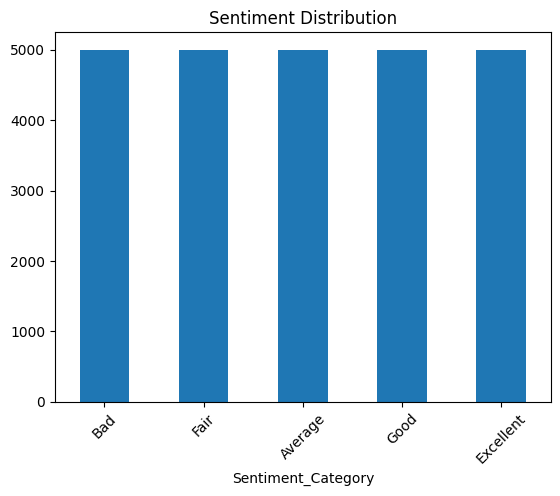

In [ ]:
df['Sentiment_Category'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df

,Review,Sentiment,Sentiment_Category,review_length,word_count,avg_word_length
0,Fast shipping but this product is very cheaply...,1,Bad,227,42,5.279070
1,This case takes so long to ship and it's not e...,1,Bad,71,15,4.437500
2,Good for not droids. Not good for iPhones. You...,1,Bad,146,29,4.866667
3,The cable was not compatible between my macboo...,1,Bad,122,20,5.809524
4,The case is nice but did not have a glow light...,1,Bad,112,20,5.333333
...,...,...,...,...,...,...
24995,These cables (lightning) are far superior to m...,5,Excellent,280,47,5.833333
24996,This unit performs exactly as advertised. I u...,5,Excellent,1010,179,5.611111
24997,I had the key cut at a local hardware store cu...,5,Excellent,302,56,5.298246
24998,I love my case I ordered from amazon. It wasn'...,5,Excellent,233,43,5.295455


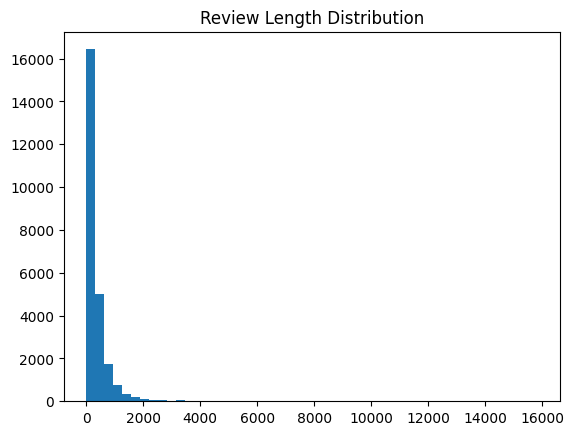

In [ ]:
plt.hist(df['review_length'], bins=50)
plt.title("Review Length Distribution")
plt.show()

In [ ]:
sns.boxplot(x='Sentiment_Category', y='review_length', data=df)
plt.xticks(rotation=45)
plt.title("Review Length by Sentiment")
plt.show()

In [ ]:
def clean_text(text):
    text = re.sub(r'[^a-zA-Z]', ' ', text.lower())
    return text.split()

all_words = []
for review in df['Review']:
    all_words.extend(clean_text(review))

common_words = Counter(all_words).most_common(20)
common_words

[('the', 99820),
 ('it', 58628),
 ('i', 57959),
 ('to', 47555),
 ('and', 43308),
 ('a', 41524),
 ('is', 29127),
 ('this', 23787),
 ('for', 23107),
 ('of', 21462),
 ('my', 19001),
 ('in', 18586),
 ('that', 17819),
 ('not', 17468),
 ('br', 17295),
 ('on', 15953),
 ('but', 15807),
 ('you', 15602),
 ('with', 15271),
 ('was', 14106)]

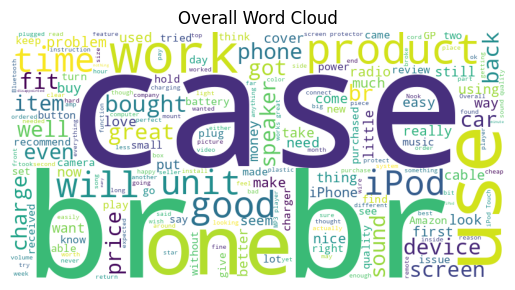

In [ ]:
text = " ".join(df['Review'])

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.imshow(wc)
plt.axis('off')
plt.title("Overall Word Cloud")
plt.show()

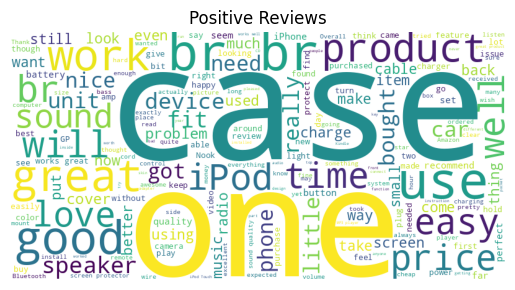

In [ ]:
positive_text = " ".join(
    df[df['Sentiment_Category'].isin(['Good', 'Excellent'])]['Review']
)

wc_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.imshow(wc_pos)
plt.axis('off')
plt.title("Positive Reviews")
plt.show()

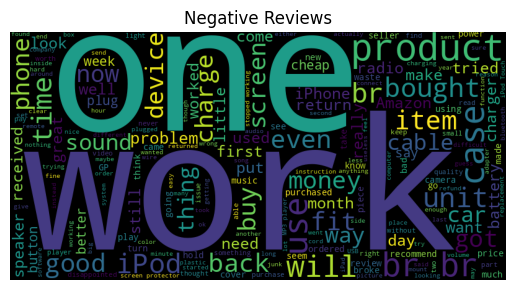

In [ ]:
negative_text = " ".join(
    df[df['Sentiment_Category'].isin(['Bad', 'Fair'])]['Review']
)

wc_neg = WordCloud(width=800, height=400).generate(negative_text)

plt.imshow(wc_neg)
plt.axis('off')
plt.title("Negative Reviews")
plt.show()

In [ ]:
import re
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Lowercase
    text = text.lower()

    # Remove special characters & numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # Tokenize
    words = text.split()

    # Remove stopwords + Lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [ ]:
df['Clean_Review'] = df['Review'].apply(preprocess_text)

/tmp/ipykernel_110202/3471857710.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Clean_Review'] = df['Review'].apply(preprocess_text)


In [ ]:
df

,Review,Sentiment,Sentiment_Category,review_length,word_count,avg_word_length,Clean_Review
0,Fast shipping but this product is very cheaply...,1,Bad,227,42,5.279070,fast shipping product cheaply made brought gra...
1,This case takes so long to ship and it's not e...,1,Bad,71,15,4.437500,case take long ship even worth dont buy
2,Good for not droids. Not good for iPhones. You...,1,Bad,146,29,4.866667,good droids good iphones cannot use feature wa...
3,The cable was not compatible between my macboo...,1,Bad,122,20,5.809524,cable compatible macbook iphone also connector...
4,The case is nice but did not have a glow light...,1,Bad,112,20,5.333333,case nice glow light disappointed product meet...
...,...,...,...,...,...,...,...
24995,These cables (lightning) are far superior to m...,5,Excellent,280,47,5.833333,cable lightning far superior cable market even...
24996,This unit performs exactly as advertised. I u...,5,Excellent,1010,179,5.611111,unit performs exactly advertised use climbing ...
24997,I had the key cut at a local hardware store cu...,5,Excellent,302,56,5.298246,key cut local hardware store cut free programm...
24998,I love my case I ordered from amazon. It wasn'...,5,Excellent,233,43,5.295455,love case ordered amazon color looked online f...


In [ ]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)

X_tfidf = vectorizer.fit_transform(df['Clean_Review'])

feature_names = vectorizer.get_feature_names_out()

scores = np.mean(X_tfidf.toarray(), axis=0)

top_words = np.argsort(scores)[-20:]

[top_words, [feature_names[i] for i in top_words]]

[array([108, 435, 708, 619,  88, 690, 765, 663, 902, 831, 314, 937, 471,
        433, 669, 359, 124, 355, 986,  90]),
 ['buy',
  'item',
  'really',
  'phone',
  'bought',
  'quality',
  'screen',
  'price',
  'time',
  'sound',
  'fit',
  'use',
  'like',
  'ipod',
  'product',
  'great',
  'case',
  'good',
  'work',
  'br']]

In [ ]:
X = df['Clean_Review']
y = df['Sentiment_Category']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.4552
              precision    recall  f1-score   support

     Average       0.37      0.33      0.35       985
         Bad       0.53      0.60      0.57      1021
   Excellent       0.57      0.59      0.58      1021
        Fair       0.37      0.36      0.36      1000
        Good       0.40      0.38      0.39       973

    accuracy                           0.46      5000
   macro avg       0.45      0.45      0.45      5000
weighted avg       0.45      0.46      0.45      5000



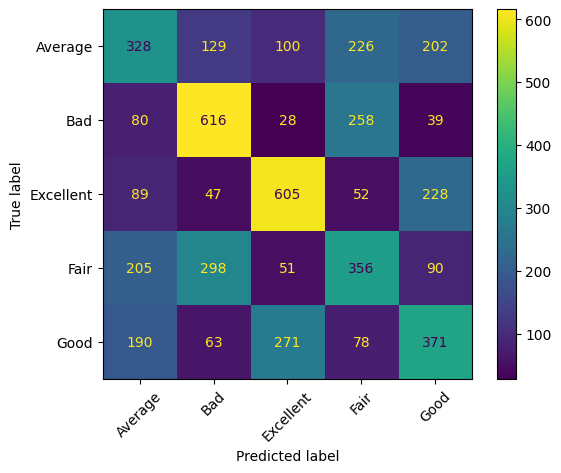

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    model,
    X_test_vec,
    y_test,
    display_labels=le.classes_,
    xticks_rotation=45
)

plt.show()

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "XGBoost": XGBClassifier(eval_metric='mlogloss')
}

In [ ]:
sample = [
    "Amazing product, highly recommend",
    "Worst purchase ever",
    "It's okay, not great"
]

sample_vec = vectorizer.transform(sample)
preds = model.predict(sample_vec)

print(le.inverse_transform(preds))

['Excellent' 'Bad' 'Average']


In [ ]:
pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [ ]:
X = df['Clean_Review']
y = df['Sentiment_Category']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

In [ ]:
vocab_size = 10000
max_length = 100

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post')

In [ ]:
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_length),

    LSTM(64, return_sequences=False),

    Dropout(0.5),

    Dense(32, activation='relu'),

    Dense(len(le.classes_), activation='softmax')  # Multi-class output
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 62ms/step - accuracy: 0.2049 - loss: 1.6097 - val_accuracy: 0.2010 - val_loss: 1.6073
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 76ms/step - accuracy: 0.2071 - loss: 1.6064 - val_accuracy: 0.2020 - val_loss: 1.6051
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.2100 - loss: 1.5931 - val_accuracy: 0.2035 - val_loss: 1.6060
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 61ms/step - accuracy: 0.2305 - loss: 1.5705 - val_accuracy: 0.2230 - val_loss: 1.6216
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 76ms/step - accuracy: 0.2343 - loss: 1.5454 - val_accuracy: 0.2027 - val_loss: 1.6665


In [ ]:
loss, accuracy = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", accuracy)

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_pred_probs = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=le.classes_))

157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step
              precision    recall  f1-score   support

     Average       0.32      0.04      0.08       985
         Bad       0.56      0.00      0.01      1021
   Excellent       0.27      0.01      0.02      1021
        Fair       0.20      0.94      0.33      1000
        Good       0.25      0.03      0.06       973

    accuracy                           0.21      5000
   macro avg       0.32      0.21      0.10      5000
weighted avg       0.32      0.21      0.10      5000



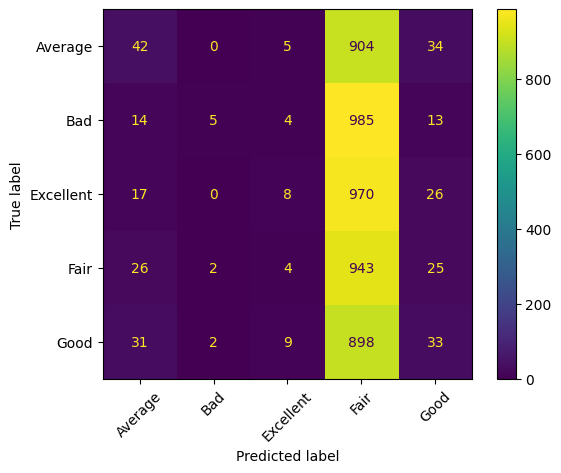

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=le.classes_,
    xticks_rotation=45
)

plt.show()

In [ ]:
sample = ["This product is amazing", "Very bad quality"]

sample_seq = tokenizer.texts_to_sequences(sample)
sample_pad = pad_sequences(sample_seq, maxlen=max_length)

preds = model.predict(sample_pad)
pred_classes = np.argmax(preds, axis=1)

print(le.inverse_transform(pred_classes))

ValueError: X has 100 features, but LogisticRegression is expecting 5000 features as input.